# Task 5 : Customer Retention Strategies

## Step 1 : Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## Step 2 : Load and Clean Dataset

In [5]:
df = pd.read_csv("Telco_Customer_Churn_Dataset .csv")

# Data Cleaning
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

df.dropna(inplace=True)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Step 3 : Calculate Customer Lifetime Value (LTV)

A simple approximation for telecom datasets is:

LTV = MonthlyCharges × Tenure

In [6]:
df["LTV"] = df["MonthlyCharges"] * df["tenure"]

df[["MonthlyCharges", "tenure", "LTV"]].head()

,MonthlyCharges,tenure,LTV
0,29.85,1,29.85
1,56.95,34,1936.30
2,53.85,2,107.70
3,42.30,45,1903.50
4,70.70,2,141.40


#### Check LTV Statistics

In [7]:
df["LTV"].describe()

count    7032.000000
mean     2283.147248
std      2264.703327
min        18.800000
25%       397.800000
50%      1394.575000
75%      3791.250000
max      8550.000000
Name: LTV, dtype: float64

## Step 4 : Categorize Customers by LTV

In [8]:
ltv_bins = [0, 1500, 4000, df["LTV"].max()]

ltv_labels = [
    "Low Value",
    "Medium Value",
    "High Value"
]

df["LTV_Group"] = pd.cut(
    df["LTV"],
    bins=ltv_bins,
    labels=ltv_labels,
    include_lowest=True
)

#### Visualize LTV Groups

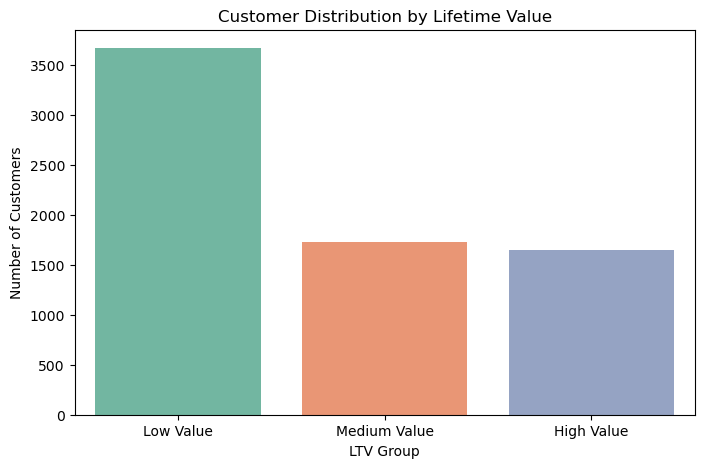

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="LTV_Group",
    hue = 'LTV_Group',
    palette="Set2"
)

plt.title("Customer Distribution by Lifetime Value")
plt.xlabel("LTV Group")
plt.ylabel("Number of Customers")

plt.show()

## Step 5 : Analyze Churn by LTV Group

In [11]:
ltv_churn = pd.crosstab(
    df["LTV_Group"],
    df["Churn"],
    normalize="index"
) * 100

ltv_churn.round(2)

Churn,No,Yes
LTV_Group,,
Low Value,66.25,33.75
Medium Value,77.24,22.76
High Value,85.41,14.59


### Visualization

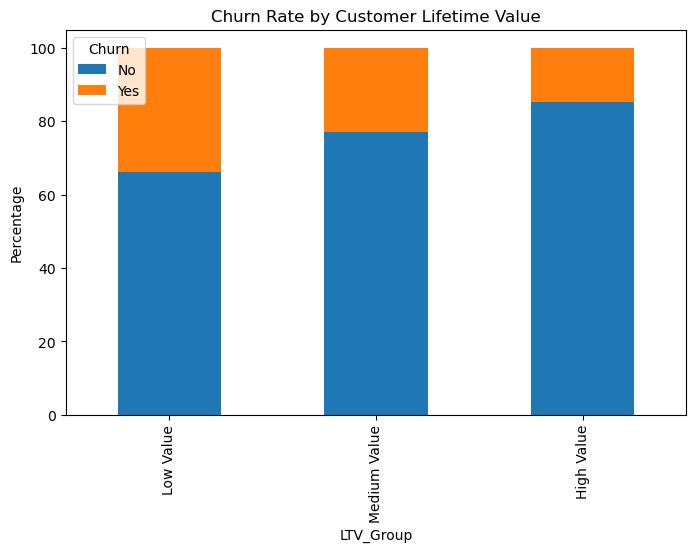

In [12]:
ltv_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Churn Rate by Customer Lifetime Value")

plt.ylabel("Percentage")

plt.show()

### Business Insight

- Customers with Low LTV tend to churn more frequently, while High LTV customers are generally more loyal.

## Step 6 : Identify High-Value Customers at Risk

In [13]:
high_value_risk = df[
    (df["LTV_Group"] == "High Value") &
    (df["Churn"] == "Yes")
]

high_value_risk.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,LTV,LTV_Group
13,0280-XJGEX,Male,0,No,No,49,Yes,Yes,Fiber optic,No,...,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,5081.30,High Value
26,6467-CHFZW,Male,0,Yes,Yes,47,Yes,Yes,Fiber optic,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,99.35,4749.15,Yes,4669.45,High Value
104,3192-NQECA,Male,0,Yes,No,68,Yes,Yes,Fiber optic,No,...,Yes,Yes,Two year,Yes,Bank transfer (automatic),110.00,7611.85,Yes,7480.00,High Value
110,0486-HECZI,Male,0,Yes,No,55,Yes,Yes,Fiber optic,Yes,...,Yes,No,Month-to-month,Yes,Electronic check,96.75,5238.90,Yes,5321.25,High Value
173,0691-JVSYA,Female,0,Yes,No,53,Yes,No,Fiber optic,No,...,Yes,Yes,One year,Yes,Bank transfer (automatic),94.85,5000.20,Yes,5027.05,High Value


### Count High-Value Customers at Risk

In [14]:
print("High Value Customers at Risk:", len(high_value_risk))

High Value Customers at Risk: 240


## Step 7 : Identify Key Factors Influencing Churn

In [15]:
key_factors = [
    "Month-to-month Contract",
    "Short Tenure",
    "High Monthly Charges",
    "Fiber Optic Internet",
    "Electronic Check Payment",
    "Senior Citizens"
]

for factor in key_factors:
    print("•", factor)

• Month-to-month Contract
• Short Tenure
• High Monthly Charges
• Fiber Optic Internet
• Electronic Check Payment
• Senior Citizens


## Step 8 : Business Recommendations

In [16]:
recommendations = pd.DataFrame({
    "Problem": [
        "Month-to-Month Contract",
        "Short Tenure",
        "High Monthly Charges",
        "Fiber Optic Users",
        "Electronic Check Users"
    ],
    "Recommendation": [
        "Offer discounts on annual contracts.",
        "Launch onboarding and loyalty programs.",
        "Provide personalized pricing or bundled plans.",
        "Improve service quality and support.",
        "Promote automatic payment methods with incentives."
    ]
})

recommendations

,Problem,Recommendation
0,Month-to-Month Contract,Offer discounts on annual contracts.
1,Short Tenure,Launch onboarding and loyalty programs.
2,High Monthly Charges,Provide personalized pricing or bundled plans.
3,Fiber Optic Users,Improve service quality and support.
4,Electronic Check Users,Promote automatic payment methods with incenti...


## Step 9 : Visualize High-Risk Customer Segments

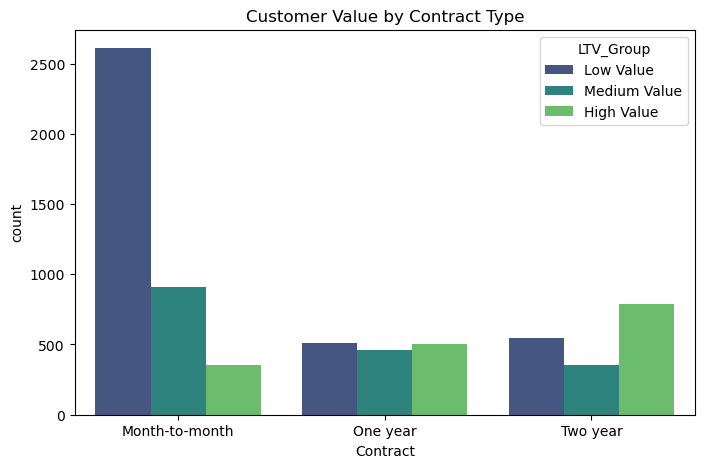

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="LTV_Group",
    palette="viridis"
)

plt.title("Customer Value by Contract Type")

plt.show()

## Step 10 : Final Conclusion

## Customer Retention Strategy - Conclusion

- The analysis identified several factors contributing to customer churn. Customers with month-to-month contracts, shorter tenure, higher monthly charges, Fiber Optic internet services, and electronic check payment methods exhibit a higher likelihood of churning.

- Although many high-value customers remain loyal, some are still at risk of leaving. The company should prioritize these customers by offering personalized retention programs, loyalty rewards, contract upgrade incentives, and proactive customer support.

- Implementing these recommendations can reduce churn, improve customer satisfaction, and increase long-term revenue.